In [1]:
# CELL 0 - Load data and set up analysis switches
from pathlib import Path
import fusiproc_utils2 as fu
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel
from nilearn import plotting, image

# -------- dataset paths -------
BASE = Path('/Users/clairenastaskin/data/Post_acquisition_parameter_sweep/sub-Forest001/ses-20250708/power_doppler_volumes_200bmodes_1.6s/svd_50')
RUN  = 'sub-Forest001_ses-20250708_task-movements_run-001_pwd.nii.gz'
PWD  = BASE / RUN
SIDE = BASE / RUN.replace('_pwd.nii.gz', '_pwd.json')

# -------- analysis switches ----
CONF_USE = dict(
    motion_6      = False,     # translation/rotation 6 params
    motion_fsl24  = True,    # Friston24 (mutually exclusive with motion_6)
    extra_fd      = False,
    dvars_stdz    = False,
    tcompcor      = False,
)

# --- temporal smoothing ------------------------------------------------------
SMOOTH_METHOD  = "boxcar"          # {"none", "boxcar", "savgol"}
SMOOTH_WINDOW  = 4                 # for boxcar (odd)
SG_PARAMS      = dict(window=7, polyorder=2)       # Savitzky–Golay (odd) 

FD_THRESH     = 0.5          # mm
RADIUS_MM     = 50.0         # mm for FD sphere

# --- subsampling (every other frame) ----------------------------------------
SUBSAMPLE_STEP = 3   # 1 = no subsampling, 2 = every other frame, etc.
subsample_tag  = f"_subsampled_{SUBSAMPLE_STEP}" if SUBSAMPLE_STEP > 1 else ""

# ---------------------------------------------------------------------------
# Build a short suffix that encodes the chosen method (+ key params)
# ---------------------------------------------------------------------------
if SMOOTH_METHOD == "none":
    smooth_tag = "_nosmooth"

elif SMOOTH_METHOD == "boxcar":
    smooth_tag = f"_boxcar{SMOOTH_WINDOW}"

elif SMOOTH_METHOD == "savgol":
    smooth_tag = f"_savgol{SG_PARAMS['window']}-{SG_PARAMS['polyorder']}"

else:
    raise ValueError(f"Unknown SMOOTH_METHOD: {SMOOTH_METHOD}")

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# CELL 1 - Mean image (from subsampled frames)
from nilearn import image

# Load full 4D and subsample every other frame
full_img = nib.load(PWD)
n_total  = full_img.shape[-1]
frame_indices = list(range(0, n_total, SUBSAMPLE_STEP))
img_subset = image.index_img(full_img, frame_indices)

mean_img  = image.mean_img(img_subset, copy_header=True)
mean_path = BASE / RUN.replace('_pwd.nii.gz', f'{subsample_tag}_mean.nii.gz')
mean_img.to_filename(mean_path)
print(f"Subsampled from {n_total} to {len(frame_indices)} frames (step={SUBSAMPLE_STEP})")
print(f"Mean image saved to {mean_path}")

Subsampled from 502 to 168 frames (step=3)
Mean image saved to /Users/clairenastaskin/data/Post_acquisition_parameter_sweep/sub-Forest001/ses-20250708/power_doppler_volumes_200bmodes_1.6s/svd_50/sub-Forest001_ses-20250708_task-movements_run-001_subsampled_3_mean.nii.gz


Data shape after subsampling: (117, 56, 45, 168)


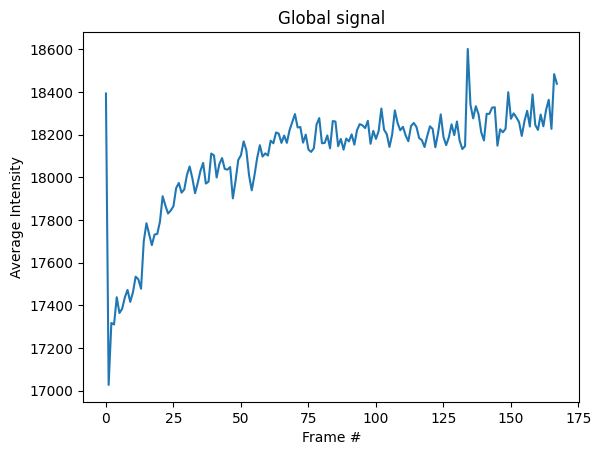

Effective TR after subsampling: 5.4002 s


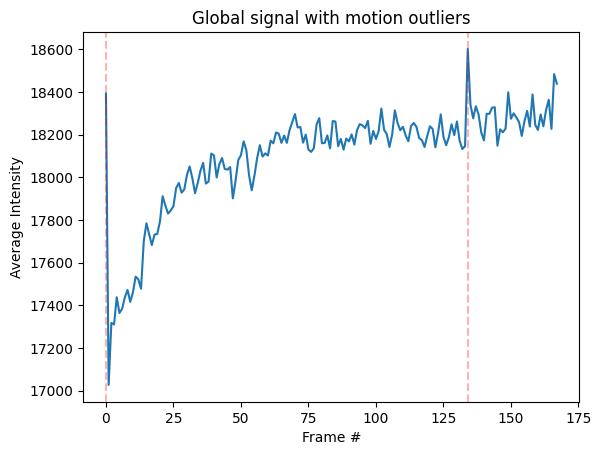

In [3]:
# CELL 2 - Global signal and motion detection
data, affine, _ = fu.load_fusi_nifti(PWD)

# Subsample to every other frame
data = data[..., ::SUBSAMPLE_STEP]
print(f"Data shape after subsampling: {data.shape}")

mask = fu.nan_mask(data)
mask_path = fu.save_nifti(mask.astype(np.uint8), affine,
                          PWD.with_name(RUN.replace('_pwd', '_mask')))

y_lim= None # (1.4e4, 2.7e4) # If we want to set the y-axis limits

gs = fu.global_signal(data)
fu.plot_global_signal(gs, BASE/"global_signal.png",y_lim)
import matplotlib.pyplot as plt

# Effective TR scales with subsample step
TR = fu.repetition_time(SIDE) * SUBSAMPLE_STEP
np.save(BASE / "t_r.npy", TR)
print(f"Effective TR after subsampling: {TR:.4f} s")

bad_gs, good_gs, fig = fu.detect_motion_via_global(gs, TR, k = 3.0, y_lim=y_lim)
fig.savefig(BASE/"global_signal_with_masked_frame.png")
skip = set(bad_gs)

In [4]:
# CELL 4 - Rigid registration
# ------------------------------------------------------------------
# Rigid registration
# ------------------------------------------------------------------
registration_path = BASE / f"registration{subsample_tag}"

if not registration_path.exists():
    registration_path.mkdir(exist_ok=True)
    
    reg, rigid, metric, stop, kept_idx = fu.register_3d_image_stack(
            np.where(np.isfinite(data), data, 0),
            reference='median',
            spacing=np.linalg.norm(affine[:3, :3], axis=0),
            skip_indices=skip,
            mask=mask,
            verbose=True)

    # Save the registration outputs
    np.save(registration_path / "reg.npy", reg)
    np.save(registration_path / "rigid.npy", rigid)
    np.save(registration_path / "metric.npy", metric)
    np.save(registration_path / "stop.npy", stop)
    np.save(registration_path / "kept_idx.npy", kept_idx)
    np.save(registration_path / "skip.npy", skip)
    # ---- Doppler movie -------------------------------------------------
    html = fu.save_doppler_movie(reg, registration_path/"Doppler_movie_after_rigid_registration.mp4")
    html  # renders in Jupyter

else:
    reg = np.load(registration_path / "reg.npy")
    rigid = np.load(registration_path / "rigid.npy")
    metric = np.load(registration_path / "metric.npy")
    stop = np.load(registration_path / "stop.npy")
    kept_idx = np.load(registration_path / "kept_idx.npy")

[frame    1] metric = -9.503000e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 8 iterations. Gradient magnitude (4.73166e-05) is less than gradient magnitude tolerance (0.0001).
[frame    2] metric = -9.515325e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 7 iterations. Gradient magnitude (9.62536e-05) is less than gradient magnitude tolerance (0.0001).
[frame    3] metric = -9.509709e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 8 iterations. Gradient magnitude (5.58892e-05) is less than gradient magnitude tolerance (0.0001).
[frame    4] metric = -9.514891e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met after 9 iterations. Gradient magnitude (2.32093e-05) is less than gradient magnitude tolerance (0.0001).
[frame    5] metric = -9.526643e-01 | stop: RegularStepGradientDescentOptimizerv4: Gradient magnitude tolerance met 

/Users/clairenastaskin/Documents/Anise/Experiments/fusiproc_utils2.py:439: RuntimeWarning: divide by zero encountered in log10
  data_db = 10*np.log10(reg_data)


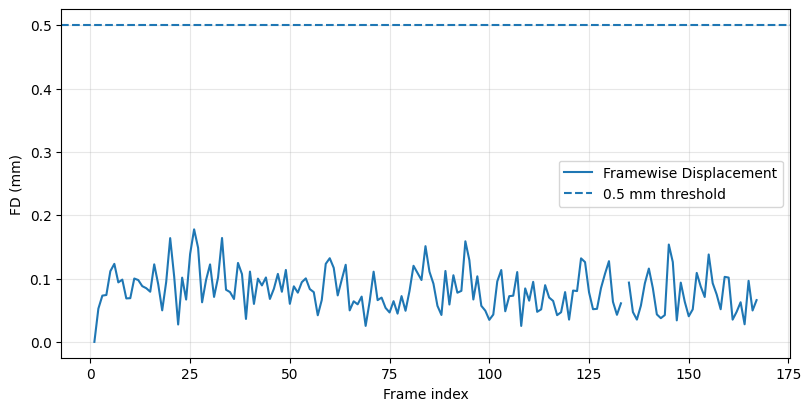

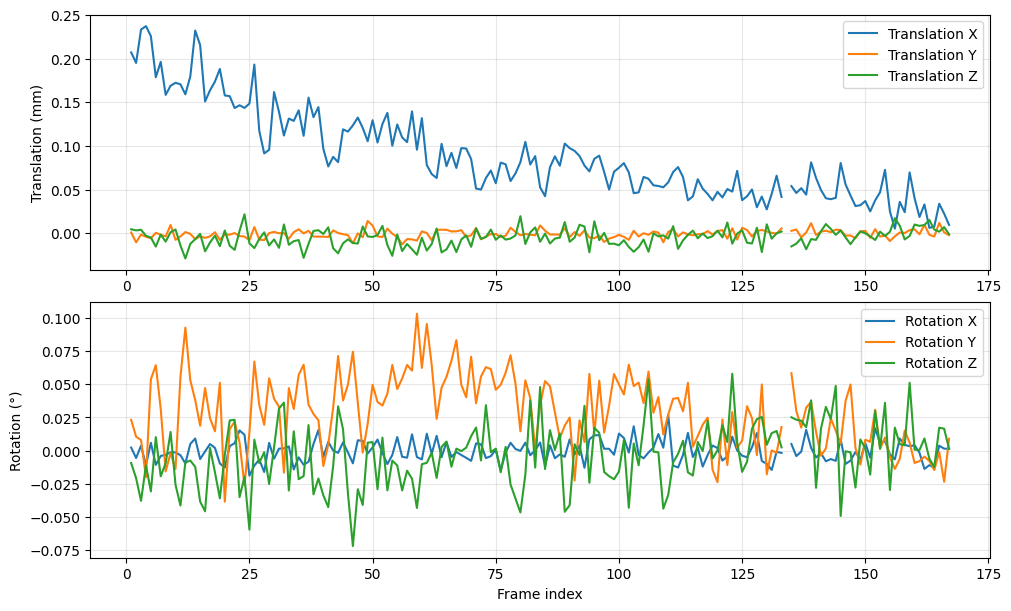

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 5 – FD outliers, censor list, NaN‑padding
# ─────────────────────────────────────────────────────────────────────────────
n_frames = data.shape[-1]

# 1. FD on the gap‑free series (after GS censoring) ---------------------------
fd = fu.framewise_displacement(rigid, radius_mm=RADIUS_MM)

fd_full = np.full(n_frames, np.nan)
fd_full[kept_idx] = fd

bad_fd = fu.plot_fd(fd_full, FD_THRESH, BASE/"framewise_displacement.png")
np.savetxt(BASE/"fd_over_0p5_indices.txt", bad_fd, fmt='%d')

# 2. update global censor list ------------------------------------------------
skip.update(int(i) for i in bad_fd)

# 3. remove newly censored frames from the registration outputs ---------------
keep_after_all = [i for i in kept_idx if i not in skip]     # T indices
sel            = np.isin(kept_idx, keep_after_all)          # boolean mask

reg_use    = reg[...,  sel]           # (x,y,z,T)
rigid_use  = rigid[:,  sel]           # (6,T)
metric_use = metric[   sel]           # (T,)
stop_use   = [s for s, ok in zip(stop, sel) if ok]

# 4. create full‑length NaN‑padded arrays ------------------------------------
retained = keep_after_all                                 # same T indices
reg_full, rigid_full, metric_full, stop_full = fu.reinstate_nans(
        reg_use, rigid_use, metric_use, stop_use,
        n_frames, retained)

fu.plot_registration_parameters(rigid_full, registration_path/"registration.png")


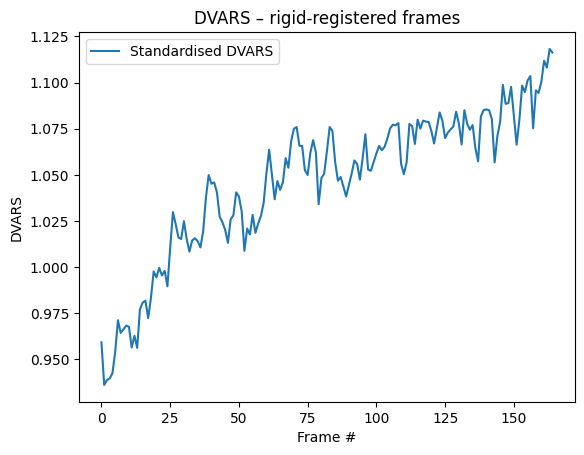

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 6 – DVARS calculation and temporal CompCor (tCompCor) confounds
# ─────────────────────────────────────────────────────────────────────────────

# Save rigid registered data (after registration, before smoothing) as a Nifti file
reg_path = fu.save_nifti(reg.astype(np.float32), affine,
                         BASE/f"fusi_data_rigid_reg{subsample_tag}.nii.gz")

# Calculate standardized DVARS, raw DVARS, and voxelwise DVARS from the registered Nifti
dvars_stdz, dvars_raw, dvars_vx = fu.calc_dvars(reg_path, mask_path)

# Plot the standardized DVARS with marked motion outliers
fu.plot_dvars(dvars_stdz, BASE/"dvars_rigid.png")

# Run tCompCor (temporal CompCor) if selected in configuration.
# This extracts confound timecourses from noise ROIs in the data for denoising.
tc_out = {}
if CONF_USE["tcompcor"]:
    tc_out = fu.run_tcompcor(reg_path, mask_path,
                             BASE/"confounds", n_components=6,
                             percentile_threshold=0.02, tr=TR)

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Cell 7 – sample mask, temporal smoothing, confounds (length‑matched)
# ─────────────────────────────────────────────────────────────────────────────
good_all    = np.array(retained, dtype=int)   # final list of frames to keep
sample_mask = good_all                        # passed to Nilearn

# -- temporal smoothing -------------------------------------------------------
if   SMOOTH_METHOD == "none":
    smoothed = reg_full.copy()

elif SMOOTH_METHOD == "boxcar":
    # Apply boxcar (moving average) smoothing: replaces each frame with the average across a sliding window.
    smoothed = fu.boxcar_smooth(reg_full, SMOOTH_WINDOW)

elif SMOOTH_METHOD == "savgol":
    # Apply Savitzky-Golay filter (polynomial smoothing filter). This method smooths the data
    # by fitting successive sub-sets of adjacent frames with a low-degree polynomial.
    smoothed = fu.savgol_smooth(reg_full, **SG_PARAMS)

else:
    raise ValueError(f"Unknown SMOOTH_METHOD \"{SMOOTH_METHOD}\"")

clean_img = nib.Nifti1Image(np.nan_to_num(smoothed), affine)
clean_img.to_filename(BASE/f"fusi_run_clean{subsample_tag}.nii.gz")

# ------------------------------------------------------------------
# Build confounds – all arrays must have n_frames rows
# ------------------------------------------------------------------
conf_list = []

# ── Motion regressors ──────────────────────────────────────────────────────
motion_full = rigid_full.T.copy()          # (n_frames, 6) – tx,ty,tz,rotx,roty,rotz
motion_full[np.isnan(motion_full)] = 0

if CONF_USE["motion_fsl24"]:
    # --- FSL‑24 construction ---
    # Compute first derivative of motion parameters (frame-to-frame changes)
    deriv = np.vstack([np.zeros((1, 6)), np.diff(motion_full, axis=0)])
    # Compute quadratic terms (squares of parameters and derivatives)
    quad  = np.square(np.hstack([motion_full, deriv]))      # 12 quadratic terms

    # Concatenate original parameters, derivatives, and all quadratic terms to obtain 24 regressors
    fsl24 = np.hstack([motion_full, deriv, quad])           # 6 + 6 + 12 = 24
    labels = (
        [f"{p}"   for p in ("tx","ty","tz","rotx","roty","rotz")] +
        [f"d{p}"  for p in ("tx","ty","tz","rotx","roty","rotz")] +
        [f"{p}2"  for p in ("tx","ty","tz","rotx","roty","rotz")] +
        [f"d{p}2" for p in ("tx","ty","tz","rotx","roty","rotz")]
    )
    # Package FSL-24 regressors into DataFrame
    conf_list.append(pd.DataFrame(fsl24, columns=labels))

elif CONF_USE["motion_6"]:
    # Use original 6 motion parameters as regressors (translations and rotations)
    conf_list.append(pd.DataFrame(
        motion_full,
        columns=["tx", "ty", "tz", "rotx", "roty", "rotz"]
    ))
    
# Frame-wise displacement (FD): Measures the sum of absolute values of the differentiated realignment estimates. 
# Commonly used to identify volumes with excessive head motion.
if CONF_USE["extra_fd"]:
    fd_col = fd_full.copy()                   # already n_frames long
    fd_col[np.isnan(fd_col)] = 0              # replace any NaNs with 0
    conf_list.append(pd.DataFrame(fd_col, columns=["fd"]))

# DVARS (D temporal derivative VARiance): Measures the root mean square variance of the temporal derivative of each brain volume; 
# used to identify signal changes due to motion or signal artifacts.

if CONF_USE["dvars_stdz"]:
    dvars_full = np.full(n_frames, np.nan)
    dvars_full[kept_idx] = dvars_stdz         # use kept_idx (not retained_gs)
    dvars_full[np.isnan(dvars_full)] = 0      # replace any NaNs with 0
    conf_list.append(pd.DataFrame(dvars_full, columns=["dvars"]))

# tCompCor (temporal CompCor): Principal component analysis of noise regions (usually WM/CSF) for nuisance regression; 
# helps remove physiological or other noise that is not head motion.

if CONF_USE["tcompcor"]:
    comps = pd.read_csv(tc_out["components"], sep="\t").to_numpy()
    tcomp_full = np.full((n_frames, comps.shape[1]), 0.0)
    tcomp_full[kept_idx] = comps              # align with same time base
    conf_list.append(pd.DataFrame(
        tcomp_full, columns=[f"tCompCor{i:02d}" for i in range(comps.shape[1])]))


# -- final dataframe -----------------------------------------------------------
confounds_df = pd.concat(conf_list, axis=1)

In [8]:
import pandas as pd
import os

if os.path.exists(BASE / 'task_events.tsv'):
    events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
else:
    task_path = list(BASE.glob('*events.tsv'))[0]
    events = pd.read_csv(task_path, sep='\t')

# events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
events["trial_type"]

0      skateboard_thumb.js
1     skateboard_middle.js
2      skateboard_pinky.js
3       skateboard_ring.js
4      skateboard_index.js
5       skateboard_ring.js
6     skateboard_middle.js
7      skateboard_pinky.js
8      skateboard_thumb.js
9      skateboard_index.js
10     skateboard_index.js
11     skateboard_pinky.js
12      skateboard_ring.js
13     skateboard_thumb.js
14    skateboard_middle.js
15    skateboard_middle.js
16     skateboard_thumb.js
17     skateboard_index.js
18     skateboard_pinky.js
19      skateboard_ring.js
20     skateboard_pinky.js
21     skateboard_thumb.js
Name: trial_type, dtype: object

/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: early_finish, late_start, response_time, control, task
  warnings.warn(


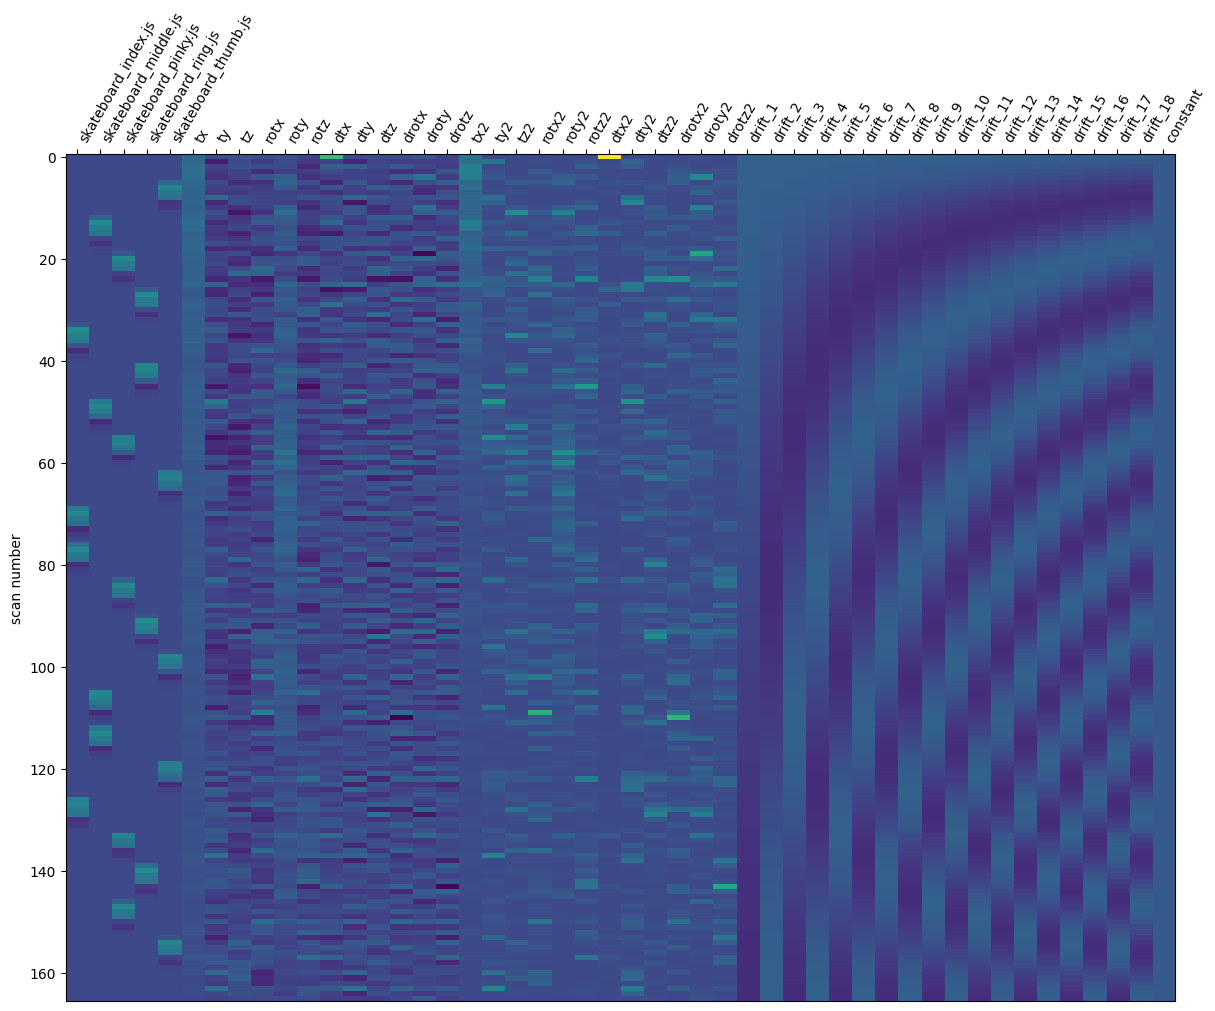

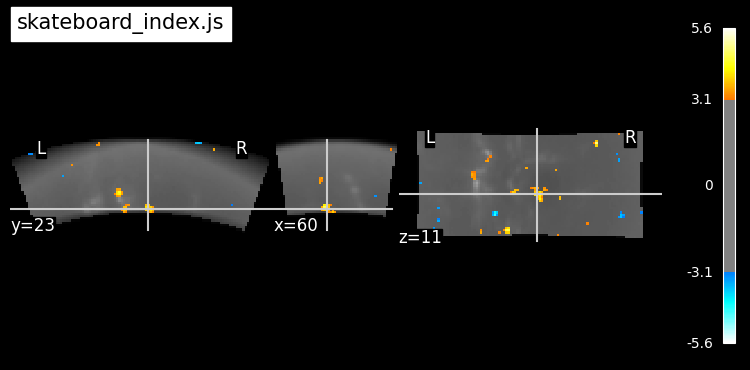

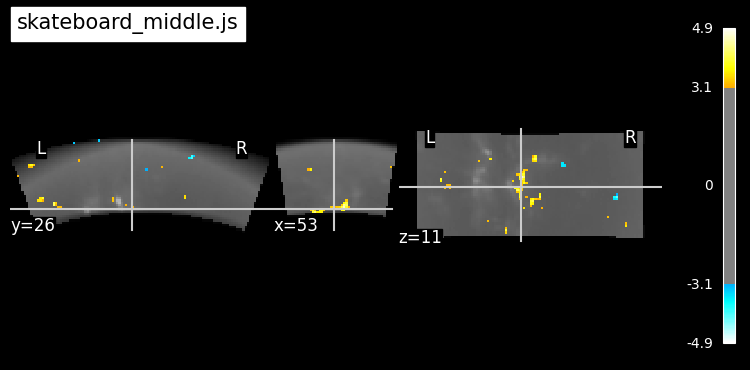

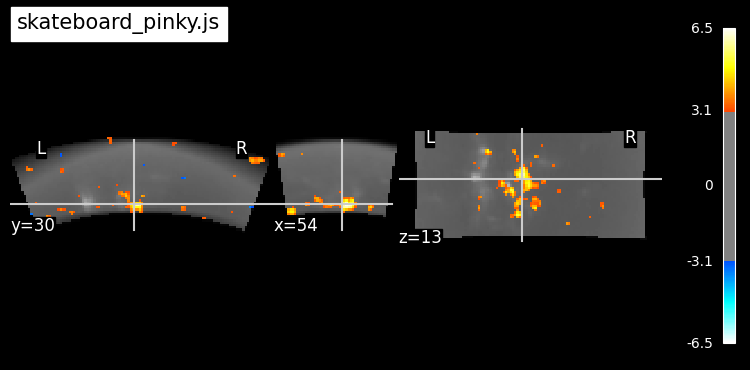

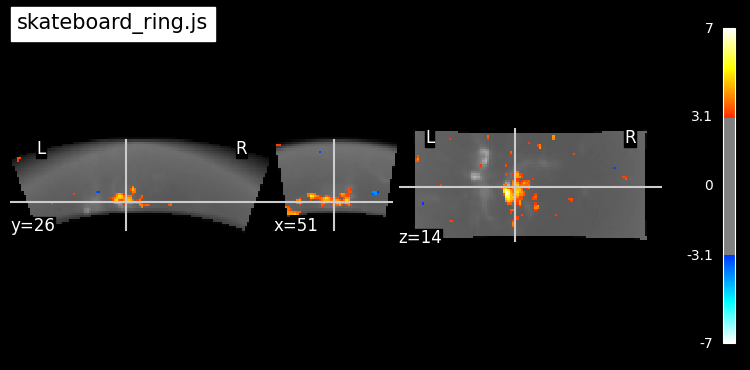

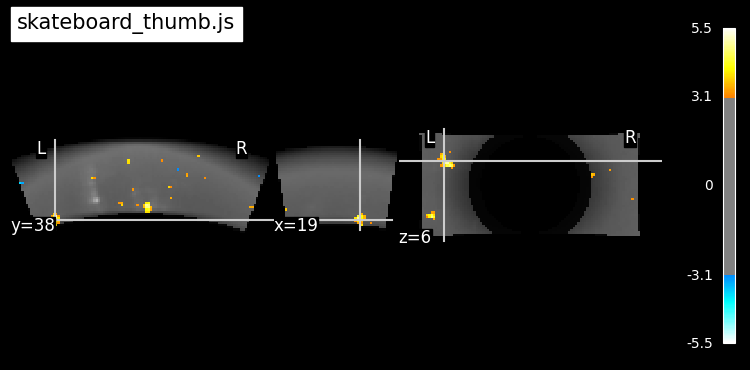

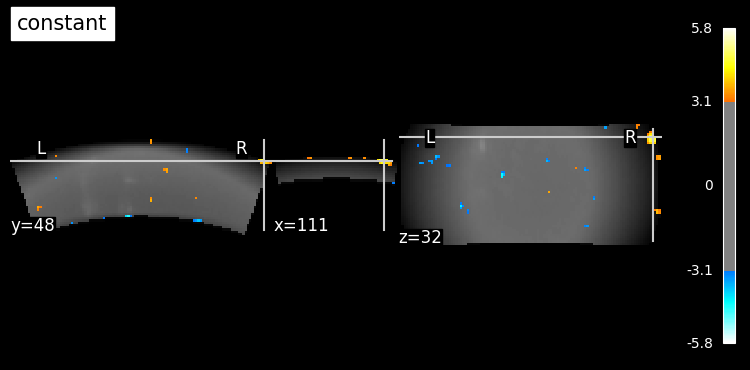

In [9]:
import json

reaction_time = 0.5  # typical reaction time assumed
with open(SIDE, 'r') as f:
    sidecar = json.load(f)


if os.path.exists(BASE / 'task_events.tsv'):
    events = pd.read_csv(BASE/"task_events.tsv", sep='\t')
else:
    task_path = list(BASE.glob('*events.tsv'))[0]
    events = pd.read_csv(task_path, sep='\t')

events["onset"] -= sidecar["VolumeTiming"][0]
events["onset"] += reaction_time

glm = FirstLevelModel(
        t_r=TR, hrf_model="glover", drift_model="cosine",
        high_pass=0.01, noise_model="ar1", standardize=True,
        smoothing_fwhm=2, mask_img=nib.Nifti1Image(mask.astype(np.uint8), affine))
glm.subject_data_ = clean_img
glm, design = fu.build_design_matrix(glm, events, confounds_df, sample_mask)
plotting.plot_design_matrix(design)
# Save design matrix to npz file
np.savez(BASE / f"design_matrix{subsample_tag}.npz", design_matrix=design.values, column_names=design.columns)

contrasts = fu.localizer_contrasts(design)


mean_img = image.mean_img(clean_img, copy_header=True)

for name, vec in contrasts.items():
    if name.startswith(("drift_", "tx", "ty", "tz", "rot", "dt", "drot")):
        continue

    zmap = glm.compute_contrast(vec, output_type="z_score")

    # ----- build filenames ---------------------------------------------------
    stem = f"{name}{smooth_tag}{subsample_tag}_z_map"
    nii_out  = BASE / f"{stem}.nii.gz"
    png_out  = BASE / f"{stem}.png"
    # ------------------------------------------------------------------------

    zmap.to_filename(nii_out)
    plotting.plot_stat_map(
        zmap, bg_img=mean_img, threshold=3.1, display_mode="ortho",
        cut_coords=plotting.find_xyz_cut_coords(zmap, activation_threshold=3.1),
        black_bg=True, title=name
    ).savefig(png_out, dpi=300)

    plotting.show()